DC OPF_IEEE 14-bus system

In [1]:
#import libraries

from pandapower.create import (
    create_gen,
    create_load,
    create_poly_cost
)

from pandapower.run import runopp, rundcopp
from pandapower import from_pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pandapower.runpm import runpm_ac_opf, runpm_dc_opf

In [2]:
#load IEEE 9-bus system
def load_network():
    return from_pickle("ieee14bus.p")

In [3]:
#plot results

def opf_results(results):
    %matplotlib inline
    plt.rc('xtick', labelsize=9)
    plt.rc('ytick', labelsize=9)
    plt.rc('legend', fontsize=9)
    plt.rc('axes', labelsize=10)
    plt.rcParams['font.size'] = 10

    sns.set_style("whitegrid", {'axes.grid' : False})
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
    ax = axes
    sns.boxplot(results.installed_mw, width=.1, ax=ax, orient="v")
    ax.set_ylabel("Installed Active Power [MW]")

In [4]:
def dcopf_gen():
    results = pd.DataFrame(columns=["installed_mw"])
    iterations = 13

    for i in range(iterations):
        #load new network
        net = load_network()

        #add new generator at bus i
        new_gen = create_gen(net, name="New Gen", bus=net.load.bus.values[i], p_mw=0, min_p_mw=0, max_p_mw=800, min_q_mvar=-600, max_q_mvar=600, vm_pu=1.025, controllable=True)

        #define cost function
        costeg = create_poly_cost(net, element=4, et='gen', cp1_eur_per_mw=-1)

        #run DC OPF
        rundcopp(net, verbose=False, delta=1e-16)

        print("Results for hosting capacity for new generation at bus " + str(net.load.bus.values[i]))

        #print ext_grid power
        for j in range(len(net.res_ext_grid)):
            print("Grid Power: " + str(round(net.res_ext_grid.p_mw[j],2)))

        #print generator power
        for j in range(len(net.res_gen)):
            print(net.gen.name[j] + " power = " + str(round(net.res_gen.p_mw[j],2)) + " MW")

        #print line loading
        for j in range(len(net.res_line)):
            print(net.line.name[j] + " loading = " + str(round(net.res_line.loading_percent[j],2)) + "%")

        #print trafo loading
        for j in range(len(net.res_trafo)):
            print(net.trafo.name[j] + " loading = " + str(round(net.res_trafo.loading_percent[j],2)) + "%")

        print("-----------------------------------------------------------------------------------")
        results.loc[i] = round(net.res_gen.p_mw[4],2)
    
    return results

In [5]:
def acopf_load():
    results = pd.DataFrame(columns=["installed_mw"])
    iterations = 13

    for i in range(iterations):
        #load new network
        net = load_network()

        #add new generator at bus i
        new_load = create_load(net, name="New Load", bus=net.load.bus.values[i], p_mw=0, min_p_mw=0, max_p_mw=200, min_q_mvar=-150, max_q_mvar=150, in_service=True, type='wye', controllable=True)

        #define cost function
        #costeg = create_poly_cost(net, element=0, et='ext_grid', cp1_eur_per_mw=1)
        #costgnew = create_poly_cost(net, element=2, et='gen', cp1_eur_per_mw=1)
        costload = create_poly_cost(net, element=13, et='load', cp1_eur_per_mw=-1)

        #run AC OPF
        runpm_ac_opf(net, verbose=False, delta=1e-16, init="pf")

        print("Results for hosting capacity for new generation at bus " + str(net.load.bus.values[i]))

        #print ext_grid power
        for j in range(len(net.res_ext_grid)):
            print("Grid Power: " + str(round(net.res_ext_grid.p_mw[j],2)))

        #print generator power
        for j in range(len(net.res_gen)):
            print(net.gen.name[j] + " power = " + str(round(net.res_gen.p_mw[j],2)) + " MW")

        #print line loading
        for j in range(len(net.res_line)):
            print(net.line.name[j] + " loading = " + str(round(net.res_line.loading_percent[j],2)) + "%")

        #print trafo loading
        for j in range(len(net.res_trafo)):
            print(net.trafo.name[j] + " loading = " + str(round(net.res_trafo.loading_percent[j],2)) + "%")

        print("-----------------------------------------------------------------------------------")
        #results.loc[i] = round(net.res_gen.p_mw[2],2)
        results.loc[i] = round(net.res_load.p_mw[13],2)
    
    return results

In [6]:
def dcopf_load():
    results = pd.DataFrame(columns=["installed_mw"])
    iterations = 13

    for i in range(iterations):
        #load new network
        net = load_network()

        #add new generator at bus i
        new_load = create_load(net, name="New Load", bus=net.load.bus.values[i], p_mw=0, q_mvar=0, max_p_mw=600, min_p_mw=0, max_q_mvar=450, min_q_mvar=-150, in_service=True, type='wye', controllable=True)

        #define cost function
        costload = create_poly_cost(net, element=13, et='load', cp1_eur_per_mw=-1)

        #run DC OPF
        rundcopp(net, verbose=False, delta=1e-16)

        print("Results for hosting capacity for new load at bus " + str(net.load.bus.values[i]))

        #print new load
        print("New load at bus " + str(net.load.bus.values[i]) + " = " + str(round(net.res_load.p_mw[13],2)) + " MW")

        #print ext_grid power
        for j in range(len(net.res_ext_grid)):
            print("Grid Power: " + str(round(net.res_ext_grid.p_mw[j],2)))

        #print generator power
        for j in range(len(net.res_gen)):
            print(net.gen.name[j] + " power = " + str(round(net.res_gen.p_mw[j],2)) + " MW")

        #print line loading
        for j in range(len(net.res_line)):
            print(net.line.name[j] + " loading = " + str(round(net.res_line.loading_percent[j],2)) + "%")

        #print trafo loading
        for j in range(len(net.res_trafo)):
            print(net.trafo.name[j] + " loading = " + str(round(net.res_trafo.loading_percent[j],2)) + "%")

        print("----------------------------------------------------------------------------------")
        results.loc[i] = round(net.res_load.p_mw[13],2)
    
    return results

Hosting Capacity of Generation

In [7]:
#running dc opf of generation
dcopf_gen_results = dcopf_gen()

Results for hosting capacity for new generation at bus 1
Grid Power: 0.0
gen2 power = 40.0 MW
gen3 power = 0.0 MW
gen4 power = 0.0 MW
gen5 power = 0.0 MW
New Gen power = 219.0 MW
line1-2/1 loading = 7.8%
line1-2/2 loading = 7.8%
line1-5 loading = 15.59%
line2-3 loading = 33.26%
line2-4 loading = 29.64%
line2-5 loading = 25.31%
line3-4 loading = 7.94%
line4-5 loading = 19.6%
line6-11 loading = 9.98%
line6-12 loading = 13.05%
line6-13 loading = 29.26%
line9-10 loading = 11.89%
line9-14 loading = 18.05%
line10-11 loading = 3.86%
line12-13 loading = 2.38%
line13-14 loading = 8.02%
trafo1 loading = 29.64%
trafo2 loading = 16.97%
trafo3 loading = 41.09%
trafo4 loading = 0.0%
trafo5 loading = 29.64%
-----------------------------------------------------------------------------------
Results for hosting capacity for new generation at bus 2
Grid Power: 0.0
gen2 power = 40.0 MW
gen3 power = 0.0 MW
gen4 power = 0.0 MW
gen5 power = 0.0 MW
New Gen power = 219.0 MW
line1-2/1 loading = 3.41%
line1-2/2

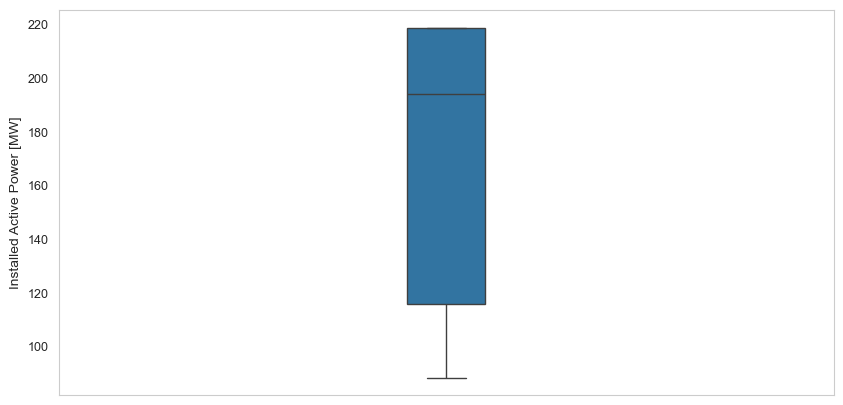

In [8]:
opf_results(dcopf_gen_results)

Hosting Capacity of Consumption

In [9]:
#run dc opf of consumption
dcopf_load_results = dcopf_load()

Results for hosting capacity for new load at bus 1
New load at bus 1 = 101.0 MW
Grid Power: 320.0
gen2 power = 40.0 MW
gen3 power = 0.0 MW
gen4 power = 0.0 MW
gen5 power = 0.0 MW
line1-2/1 loading = 50.85%
line1-2/2 loading = 50.85%
line1-5 loading = 38.26%
line2-3 loading = 29.43%
line2-4 loading = 21.63%
line2-5 loading = 14.47%
line3-4 loading = 11.77%
line4-5 loading = 30.8%
line6-11 loading = 11.52%
line6-12 loading = 13.27%
line6-13 loading = 30.05%
line9-10 loading = 10.35%
line9-14 loading = 17.04%
line10-11 loading = 5.39%
line12-13 loading = 2.6%
line13-14 loading = 9.03%
trafo1 loading = 28.71%
trafo2 loading = 16.44%
trafo3 loading = 42.54%
trafo4 loading = 0.0%
trafo5 loading = 28.71%
----------------------------------------------------------------------------------
Results for hosting capacity for new load at bus 2
New load at bus 2 = 101.0 MW
Grid Power: 320.0
gen2 power = 40.0 MW
gen3 power = 0.0 MW
gen4 power = 0.0 MW
gen5 power = 0.0 MW
line1-2/1 loading = 48.83%
line

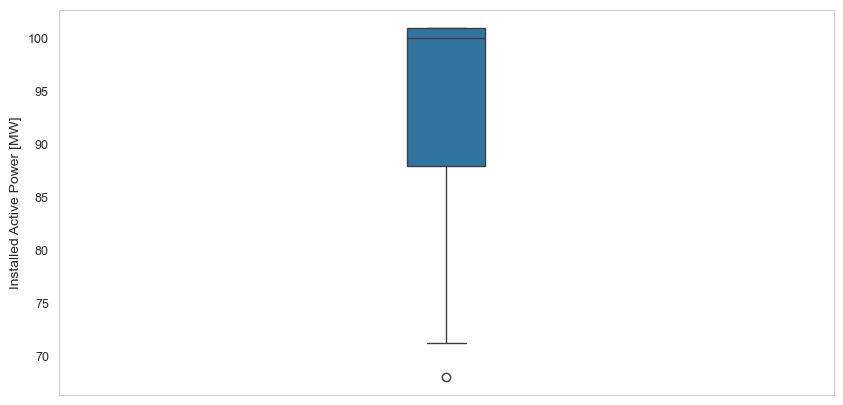

In [10]:
opf_results(dcopf_load_results)

In [11]:
#acopf_load()